# 1. Getting started

**Oroscope** searches digital elevation models for ground that could host a
particle-astrophysics observatory. It answers one question, and the fact that it is a
single question is what lets one engine serve experiments that look nothing alike:

> From this patch of ground, is there a target surface at the **right range**, in the
> **right direction**, at the **right relative orientation**, with the **right matter
> behind it**?

GRAND wants terrain a few degrees below the horizon and tens of kilometres away, to
catch radio from air showers started by Earth-skimming tau neutrinos. TAMBO wants a
canyon wall two to five kilometres across, to catch the particles themselves. They
differ in their *numbers*, not in their *structure*.

This notebook builds a piece of terrain, scans it, and reads the result. Nothing here
needs a real DEM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import oroscope

print(f"oroscope {oroscope.__version__}")

oroscope 0.1.0


> **One import.** `import oroscope` is the whole setup — every function these notebooks
> use is on it, and the submodules stay available when a narrower namespace reads better
> (`from oroscope import physics`). Install it first, with `pip install oroscope`, or
> `pip install -e .` from a clone.

## A piece of terrain

A DEM is just a 2-D array of elevations plus a statement of how big a pixel is on the
ground. Here is a plain west-facing slope with a ridge to its east — the geometry a
detector on the slope would use to look *at* the ridge.

pixel: 30.7 m north-south, 29.8 m east-west
resolution source: user-specified


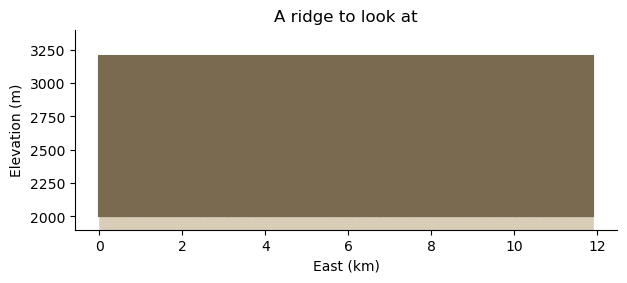

In [2]:
n = 400                      # pixels on a side
cell_deg = 1 / 3600.0        # 1 arc-second, as SRTM and AW3D30 supply

# Metric pixel sizes differ on each axis away from the equator, because a degree of
# longitude shrinks with the cosine of the latitude. resolve_grid_geometry does that.
grid = oroscope.resolve_grid_geometry("no-such-file.tif", -15.6, cell_size_deg=cell_deg)
print(f"pixel: {grid.cell_size_y:.1f} m north-south, {grid.cell_size_x:.1f} m east-west")
print(f"resolution source: {grid.source}")

cols = np.arange(n)[None, :].repeat(n, 0)
x_m = cols * grid.cell_size_x

# A ridge 1.2 km high centred 6.5 km east, on a plain at 2 km
z = (2000.0 + 1200.0 * np.exp(-((x_m - 6500.0) / 700.0) ** 2)).astype(np.float32)

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(x_m / 1000, z[0], color="#7A6A4F")
ax.fill_between(x_m[0] / 1000, 1900, z[0], color="#D9CDB8")
ax.set_xlabel("East (km)")
ax.set_ylabel("Elevation (m)")
ax.set_title("A ridge to look at")
ax.set_ylim(1900, 3400)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Scanning one candidate

A *candidate* is a pixel the search is considering, given as `[row, col, aspect_deg]`.
The aspect is the downhill direction, and the scan fans its azimuths around it.

Put a detector on the plain west of the ridge, facing east.

In [3]:
candidate = np.array([[200.0, 60.0, 90.0]])     # row, col, aspect: due east

out = oroscope.scan(
    candidate, z, grid,
    n_azimuths=1, half_width_deg=0.0, use_aspect=True,   # look along the aspect only
    elev_min_deg=-3.0, elev_max_deg=3.0, n_elev_bins=12,
    min_dist_km=1.0, max_dist_km=10.0, max_range_m=10000.0,
)

for key in ("cells", "solid_angle_sr", "mean_distance_m", "max_depth_gcm2",
            "horizon_deg", "target_slope_deg"):
    print(f"{key:>18}: {out[key][0]:,.3f}")

             cells: 6.000
    solid_angle_sr: 0.329
   mean_distance_m: 3,459.807
    max_depth_gcm2: 962,897.660
       horizon_deg: 14.336
  target_slope_deg: 18.895


What those mean:

- **`cells`** — how many (azimuth, elevation) directions were accepted.
- **`solid_angle_sr`** — the accepted solid angle. This is the quantity an aperture is
  proportional to, so it is the closest single number to "how good is this site".
- **`mean_distance_m`** — mean distance to the first terrain the ray strikes, which is
  where a tau would exit the rock.
- **`max_depth_gcm2`** — the most rock any accepted direction has behind it.
- **`horizon_deg`** — the highest terrain angle seen. Note it is **positive**: the
  ridge stands above the horizontal, so the whole ±3° window sits *below* the local
  horizon. That is the normal case in mountains, and it is why a simple hit/no-hit test
  discriminates so poorly.
- **`target_slope_deg`** — how steep the struck terrain is, along the arrival azimuth.

## Distance decides what is visible

Move the detector and the accepted geometry changes. The scan only accepts a direction
whose first intersection falls inside the distance window.

In [4]:
for col in (20, 60, 120, 180):
    cand = np.array([[200.0, float(col), 90.0]])
    r = oroscope.scan(cand, z, grid, n_azimuths=1, half_width_deg=0.0,
                      use_aspect=True, elev_min_deg=-3.0, elev_max_deg=3.0,
                      n_elev_bins=12, min_dist_km=1.0, max_dist_km=10.0,
                      max_range_m=10000.0)
    gap_km = (6500.0 - col * grid.cell_size_x) / 1000.0
    print(f"col {col:>4}  {gap_km:5.2f} km from the ridge   "
          f"cells {int(r['cells'][0]):>3}   Omega {r['solid_angle_sr'][0]:.3f} sr   "
          f"d {r['mean_distance_m'][0]:>7,.0f} m")

col   20   5.90 km from the ridge   cells   6   Omega 0.329 sr   d   4,721 m
col   60   4.71 km from the ridge   cells   6   Omega 0.329 sr   d   3,460 m
col  120   2.93 km from the ridge   cells   5   Omega 0.274 sr   d   1,644 m
col  180   1.14 km from the ridge   cells   0   Omega 0.000 sr   d       0 m


The closest candidate accepts nothing: the ridge is inside the 1 km minimum, so every
direction that strikes it is rejected as too near. That minimum exists because the tau
needs room to decay and the shower room to develop.

## Where to go next

- **[2. The arrival scan](02_the_arrival_scan.ipynb)** — how one walk fills every
  elevation bin, and what the observables actually measure.
- **[3. The physics toolkit](03_physics_toolkit.ipynb)** — the closed-form physics,
  usable on its own with no terrain at all.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Next: [The arrival scan](02_the_arrival_scan.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*